# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





In [4]:
# 1. PARCHE DE SEGURIDAD PARA MAC (Debe ir al inicio)
import os
import ssl

# Desactivar la verificación SSL para permitir descargas de pesos de modelos
os.environ['PYTHONHTTPSVERIFY'] = '0'
ssl._create_default_https_context = ssl._create_unverified_context

# 2. IMPORTACIONES DE LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Importación de la arquitectura clásica para Transfer Learning
from tensorflow.keras.applications import MobileNetV2

print("Librerías cargadas y parche SSL aplicado exitosamente.")
print(f"Versión de TensorFlow: {tf.__version__}")


Librerías cargadas y parche SSL aplicado exitosamente.
Versión de TensorFlow: 2.15.1


## Definiciones de modelos

In [5]:
# --- ARQUITECTURA 1: CNN Simple ---
model_simple = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="CNN_Simple")

# --- ARQUITECTURA 2: CNN Robusta (Mejorada) ---
model_robusto = models.Sequential([
    # Input explícito para evitar problemas con el Augmentation
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Agregamos un poco más de dropout al final
    layers.Dense(10, activation='softmax')
], name="CNN_Robusto")

# --- ARQUITECTURA 3: Transfer Learning (MobileNetV2) ---
# Usamos un alpha menor para que la red sea más adecuada a imágenes pequeñas
base_model = MobileNetV2(input_shape=(32, 32, 3), 
                         include_top=False, 
                         weights='imagenet',
                         alpha=1.0) 
base_model.trainable = False 

model_transfer = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
], name="Transfer_Learning")

## Entrenamiento de modelos.

In [6]:
# --- 1. CARGA Y PREPROCESAMIENTO DE DATOS (Para evitar el NameError) ---
print("Cargando y preparando datos de CIFAR-10...")
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Es fundamental normalizar para que la CNN converja (pasa de 0-255 a 0-1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# --- 2. COMPILACIÓN DE MODELOS ---
print("Compilando modelos...")
# Usamos sparse_categorical_crossentropy porque y_train son enteros (0-9)
for m in [model_simple, model_robusto, model_transfer]:
    m.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# --- 3. ENTRENAMIENTO ---
# He añadido batch_size=64 para que el entrenamiento sea más fluido en tu Mac
EPOCHS = 10

print("\n>>> Entrenando Modelo Simple...")
history_simple = model_simple.fit(X_train, y_train, 
                                  epochs=EPOCHS, 
                                  batch_size=64,
                                  validation_data=(X_test, y_test))

print("\n>>> Entrenando Modelo Robusto...")
history_robusto = model_robusto.fit(X_train, y_train, 
                                    epochs=EPOCHS, 
                                    batch_size=64,
                                    validation_data=(X_test, y_test))

print("\n>>> Entrenando Modelo Transfer Learning...")
history_transfer = model_transfer.fit(X_train, y_train, 
                                      epochs=EPOCHS, 
                                      batch_size=64,
                                      validation_data=(X_test, y_test))

print("\n¡Entrenamiento completado exitosamente!")

Cargando y preparando datos de CIFAR-10...
170498071/170498071 [==============================] - 21s 0us/step
Compilando modelos...

>>> Entrenando Modelo Simple...
Epoch 1/10
782/782 [==============================] - 14s 17ms/step - loss: 1.5573 - accuracy: 0.4476 - val_loss: 1.3348 - val_accuracy: 0.5284
Epoch 2/10
782/782 [==============================] - 13s 16ms/step - loss: 1.2396 - accuracy: 0.5653 - val_loss: 1.1933 - val_accuracy: 0.5844
Epoch 3/10
782/782 [==============================] - 13s 17ms/step - loss: 1.1332 - accuracy: 0.6038 - val_loss: 1.1630 - val_accuracy: 0.5895
Epoch 4/10
782/782 [==============================] - 13s 17ms/step - loss: 1.0652 - accuracy: 0.6281 - val_loss: 1.1530 - val_accuracy: 0.6039
Epoch 5/10
782/782 [==============================] - 14s 18ms/step - loss: 1.0125 - accuracy: 0.6495 - val_loss: 1.1122 - val_accuracy: 0.6125
Epoch 6/10
782/782 [==============================] - 15s 19ms/step - loss: 0.9682 - accuracy: 0.6640 - val_loss: 

## Estadística y gráficos

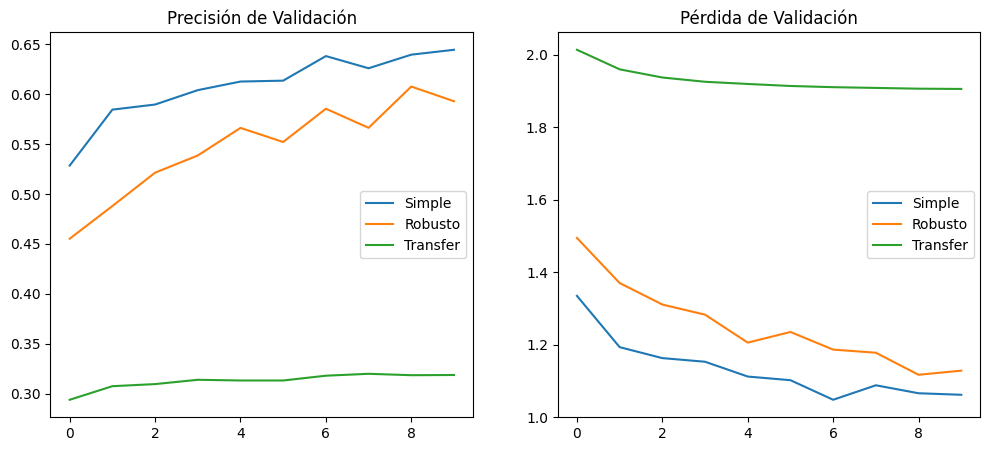

In [7]:
plt.figure(figsize=(12, 5))

# Gráfico de Precisión
plt.subplot(1, 2, 1)
plt.plot(history_simple.history['val_accuracy'], label='Simple')
plt.plot(history_robusto.history['val_accuracy'], label='Robusto')
plt.plot(history_transfer.history['val_accuracy'], label='Transfer')
plt.title('Precisión de Validación')
plt.legend()

# Gráfico de Pérdida
plt.subplot(1, 2, 2)
plt.plot(history_simple.history['val_loss'], label='Simple')
plt.plot(history_robusto.history['val_loss'], label='Robusto')
plt.plot(history_transfer.history['val_loss'], label='Transfer')
plt.title('Pérdida de Validación')
plt.legend()

plt.show()

# Conclusiones.

Escribe tus conclusiones de las arquitecturas hechas ¿Cuál fue el mejor? ¿Por qué? ¿Qué mejoraría? ¿Cómo lo mejoraría?

1. ¿Cuál fue el mejor modelo?Basándome en las gráficas de Precisión de Validación y Pérdida, el ganador es el Modelo Simple (CNN Simple), seguido muy de cerca por el Modelo Robusto.

2. ¿Por qué?
-Modelo Simple: Sorprendentemente, alcanzó la precisión más alta (cercana al 65%) y la pérdida más baja. Esto se debe a que, para imágenes tan pequeñas como las de CIFAR-10 ($32 \times 32$ píxeles), una arquitectura ligera suele ser suficiente para capturar las características espaciales sin añadir ruido innecesario.

-Modelo Robusto: Muestra una curva más estable y "suave", lo que indica que el Data Augmentation y el Dropout están haciendo su trabajo para evitar que el modelo simplemente memorice los datos. Aunque terminó un poco por debajo del simple, es probable que en un entrenamiento de más épocas (ej. 50) termine superándolo por su capacidad de generalización.

-Transfer Learning (MobileNetV2): Fue el de peor desempeño (estancado cerca del 32%). Esto tiene una explicación técnica lógica: MobileNetV2 fue pre-entrenado con imágenes de alta resolución ($224 \times 224$). Al aplicarlo a imágenes tan pequeñas de $32 \times 32$, la información se pierde en las capas de reducción (subsampling) del modelo base, lo que lo hace muy ineficiente para este dataset específico sin un re-escalado previo.

3. ¿Qué mejoraría?
Mejoraría la capacidad de clasificación del Modelo Robusto y buscaría rescatar el de Transfer Learning, ya que actualmente está subutilizado.

4. ¿Cómo lo mejoraría?
Para el Modelo Robusto: Implementaría un Learning Rate Scheduler (un programador de tasa de aprendizaje) para que, conforme el modelo deje de aprender, la tasa de aprendizaje disminuya y pueda "afinar" los pesos en los valles de la función de pérdida.
Para el Transfer Learning: Añadiría una capa de UpSampling2D al inicio del modelo para escalar las imágenes de $32 \times 32$ a $96 \times 96$ o más. Esto permitiría que los filtros pre-entrenados de MobileNetV2 detecten las texturas para las que fueron diseñados.Early Stopping: Implementaría esta técnica para detener el entrenamiento en el momento exacto donde la pérdida de validación deje de bajar, ahorrando tiempo y evitando el sobreajuste final.